# Crypto Price Prediction — v8

**Machine Learning and Data Mining** — ECPS 211 Winter 2026

**v8 improvements over v7:**
1. **XGBoost** — nonlinear model capturing regime interactions
2. **Technical indicators** — RSI(14), MACD(12/26/9), Bollinger Band position, ATR(14), OBV momentum
3. **Multi-horizon returns** — 3d, 7d, 14d, 30d cumulative returns
4. **BTC cross-asset features** — BTC lagged returns (1–3 day) + BTC/asset rotation proxy for altcoin prediction
5. **Return-based Ridge** — stationarity fix (return lags instead of price lags)
6. **Improved LSTM** — 64→32 units, dropout 0.2, early stopping, LR scheduling
7. **Weighted ensemble** — Ridge + XGBoost + LSTM weighted by validation Dir.Acc
8. **Training methodology (§4):** **Expanding-window evaluation** (walk-forward, mean ± std across test windows); **Optuna** for Ridge & XGBoost hyperparameter tuning; **LSTM sequence boundary** documented (no val leakage).
9. **Stacking meta-learner (§3b)** — Logistic Regression trained on validation OOF predictions (Ridge + XGBoost + LSTM) to predict direction; aligns second-level model with Dir.Acc objective.
10. **Direct XGBoost Classifier (§3c)** — separate up/down classifier trained with AUC objective (binary:logistic + roc_auc CV scoring); directional accuracy compared to regression models.
11. **Error analysis (§5):** Regime-conditional evaluation (MAE/RMSE/Dir.Acc by volatility tercile), calibration/reliability diagram (Dir.Acc by predicted-move size), temporal patterns (directional-error autocorrelation, rolling 30-day Dir.Acc).

Set `ASSET` below and **Runtime → Run all**.

In [1]:
# ── CONFIG ────────────────────────────────────────────────────────────
ASSET = "ETC-USD"          # Change to BTC-USD, ETH-USD, XRP-USD, etc.
N_LAGS = 30                # Number of return lags
SEQ_LEN = 30               # LSTM sequence length
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15            # test = 1 - train - val = 0.15
RANDOM_STATE = 42

In [2]:
# Pin numpy/pandas for Colab + TensorFlow compatibility (avoid numpy 2.2+ / pandas 3.x)
!pip install -q "numpy>=1.26,<2.2" "pandas>=2.2.3,<3"
!pip install -q yfinance pyarrow scikit-learn tensorflow matplotlib seaborn xgboost ta optuna
print("Install done. Ignore other pip conflict warnings for this notebook.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 152.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 27.1

**Colab:** If you see `ValueError: numpy.dtype size changed` or `ImportError: cannot load module more than once per process`, use **Runtime → Restart session**, then run from the top. Only run the fix cell below if the dtype error persists; then restart again and run from the top (skip the fix cell next time).

In [3]:
# Fix numpy/pandas (run only if you saw "numpy.dtype size changed"). Then Restart session and re-run from top.
# !pip install --force-reinstall --no-cache-dir "numpy>=1.26,<2.2" "pandas>=2.2.3,<3" -q
print("If you uncommented and ran the line above: Runtime → Restart session, then run all from top (skip this cell next time).")

If you uncommented and ran the line above: Runtime → Restart session, then run all from top (skip this cell next time).


In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from pathlib import Path

# sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

# XGBoost
import xgboost as xgb

# Technical indicators
import ta

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import layers, callbacks

print(f"NumPy {np.__version__}, Pandas {pd.__version__}, XGBoost {xgb.__version__}, TF {tf.__version__}")

NumPy 2.0.2, Pandas 2.3.3, XGBoost 3.2.0, TF 2.20.0


## 1. Data Loading

**Main series:** The asset you set as `ASSET` (e.g. ETC-USD) is the one we download and predict — its **price** and **returns** are the target. **BTC-USD** is downloaded only as an **auxiliary** series to build cross-asset features (BTC lagged returns, BTC/asset rotation). All model targets and reported prices are for `ASSET`, not BTC.

In [5]:
# Download main asset
raw = yf.download(ASSET, start="2017-01-01", end=None, progress=False, auto_adjust=True)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.droplevel(1)
raw.index = pd.to_datetime(raw.index).tz_localize(None)
raw = raw.sort_index().ffill().dropna()

# Download BTC for cross-asset features
btc_raw = yf.download("BTC-USD", start="2017-01-01", end=None, progress=False, auto_adjust=True)
if isinstance(btc_raw.columns, pd.MultiIndex):
    btc_raw.columns = btc_raw.columns.droplevel(1)
btc_raw.index = pd.to_datetime(btc_raw.index).tz_localize(None)
btc_raw = btc_raw.sort_index().ffill().dropna()

print(f"{ASSET}: {len(raw)} rows, {raw.index[0].date()} to {raw.index[-1].date()}  <- main series (we predict this)")
print(f"BTC-USD: {len(btc_raw)} rows  <- used only as cross-asset features, not the prediction target")

ETC-USD: 3036 rows, 2017-11-09 to 2026-03-02
BTC-USD: 3348 rows


## 2. Enhanced Feature Engineering (Fix #2 — MODEL_IMPROVEMENT_ASSESSMENT.md §2)

Implements **Quick Win #2** and **Section 2**: RSI(14), MACD(12/26/9), Bollinger position, ATR(14) + ATR% (scale-invariant), OBV 7d/14d change, multi-horizon returns (3/7/14/30d), calendar (dow/month sine-cosine), BTC lagged returns (1–3), BTC dominance proxy change. **~55 features:** 30 return lags + extra columns below.

In [6]:
# ── Base features ─────────────────────────────────────────────
df = pd.DataFrame(index=raw.index)
df["price"] = raw["Close"].values
df["high"] = raw["High"].values
df["low"] = raw["Low"].values
df["volume"] = raw["Volume"].values.astype(float)
df["volume"] = df["volume"].fillna(0)

# Returns
df["ret"] = (df["price"] - df["price"].shift(1)) / (df["price"].shift(1) + 1e-12)
df["log_volume"] = np.log1p(df["volume"])
df["volatility_14"] = df["ret"].rolling(14).std()

# ── Technical indicators (ta library) ────────────────────────
close_series = df["price"]

# RSI (14)
df["rsi_14"] = ta.momentum.RSIIndicator(close_series, window=14).rsi()

# MACD (12, 26, 9)
macd_ind = ta.trend.MACD(close_series, window_slow=26, window_fast=12, window_sign=9)
df["macd"] = macd_ind.macd()
df["macd_signal"] = macd_ind.macd_signal()
df["macd_diff"] = macd_ind.macd_diff()

# Bollinger Bands position (20, 2)
bb_ind = ta.volatility.BollingerBands(close_series, window=20, window_dev=2)
bb_upper = bb_ind.bollinger_hband()
bb_lower = bb_ind.bollinger_lband()
df["bb_position"] = (close_series - bb_lower) / (bb_upper - bb_lower + 1e-12)

# ATR (14) + scale-invariant ATR% (assessment §2a: volatility measure differing from rolling std)
atr_ind = ta.volatility.AverageTrueRange(high=df["high"], low=df["low"], close=close_series, window=14)
df["atr_14"] = atr_ind.average_true_range()
df["atr_14_pct"] = df["atr_14"] / (df["price"] + 1e-12)

# OBV momentum (7d and 14d change) — assessment §2a
obv_ind = ta.volume.OnBalanceVolumeIndicator(close=close_series, volume=df["volume"])
df["obv"] = obv_ind.on_balance_volume()
df["obv_chg_7d"] = df["obv"].pct_change(7)
df["obv_chg_14d"] = df["obv"].pct_change(14)

# ── Multi-horizon returns ────────────────────────────────────
for horizon in [3, 7, 14, 30]:
    df[f"ret_{horizon}d"] = df["price"].pct_change(horizon)

# ── Calendar cyclical features ───────────────────────────────
dow = df.index.dayofweek  # 0..6
month = df.index.month    # 1..12
df["dow_sin"] = np.sin(2 * np.pi * dow / 7.0)
df["dow_cos"] = np.cos(2 * np.pi * dow / 7.0)
df["month_sin"] = np.sin(2 * np.pi * (month - 1) / 12.0)
df["month_cos"] = np.cos(2 * np.pi * (month - 1) / 12.0)

# ── BTC cross-asset features ────────────────────────────────
btc_ret = btc_raw["Close"].pct_change()
for lag in [1, 2, 3]:
    col_name = f"btc_ret_lag{lag}"
    btc_lagged = btc_ret.shift(lag)
    btc_lagged.name = col_name
    df = df.join(btc_lagged, how="left")

# BTC dominance proxy change (rotation signal):
# ratio of BTC price to target asset price, then 1-day change.
btc_close = btc_raw["Close"].rename("btc_close")
df = df.join(btc_close, how="left")
df["btc_dominance_proxy_chg"] = (df["btc_close"] / (df["price"] + 1e-12)).pct_change()

# ── Clean up NaNs from warmup ────────────────────────────────
df = df.iloc[40:].copy()  # Warmup for MACD/30-lag/OBV change windows
for c in ["btc_ret_lag1", "btc_ret_lag2", "btc_ret_lag3", "btc_close", "btc_dominance_proxy_chg"]:
    if c in df.columns:
        df[c] = df[c].ffill().fillna(0)
df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

# Feature columns for Ridge/XGBoost (beyond lags)
EXTRA_FEATURE_COLS = [
    "log_volume", "volatility_14",
    "rsi_14", "macd", "macd_signal", "macd_diff", "bb_position", "atr_14", "atr_14_pct",
    "obv_chg_7d", "obv_chg_14d",
    "ret_3d", "ret_7d", "ret_14d", "ret_30d",
    "dow_sin", "dow_cos", "month_sin", "month_cos",
    "btc_ret_lag1", "btc_ret_lag2", "btc_ret_lag3", "btc_dominance_proxy_chg",
]

# LSTM feature columns (per timestep in sequence)
LSTM_FEATURE_COLS = [
    "ret", "log_volume", "volatility_14",
    "rsi_14", "macd_diff", "bb_position", "atr_14", "atr_14_pct",
    "obv_chg_7d", "ret_3d", "ret_7d", "ret_14d",
    "dow_sin", "dow_cos",
    "btc_ret_lag1", "btc_dominance_proxy_chg",
]

print(f"DataFrame shape after cleanup: {df.shape}")
print(f"Extra feature columns: {len(EXTRA_FEATURE_COLS)}")
print(f"Total features for Ridge/XGBoost: {N_LAGS} lags + {len(EXTRA_FEATURE_COLS)} extra = {N_LAGS + len(EXTRA_FEATURE_COLS)}")
print(f"LSTM features per timestep: {len(LSTM_FEATURE_COLS)}")

DataFrame shape after cleanup: (2996, 30)
Extra feature columns: 23
Total features for Ridge/XGBoost: 30 lags + 23 extra = 53
LSTM features per timestep: 16


In [7]:
# ── Time-based split ──────────────────────────────────────────
n = len(df)
train_end = int(TRAIN_FRAC * n)
val_end = int((TRAIN_FRAC + VAL_FRAC) * n)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print(f"Train: {len(train_df)} rows ({train_df.index[0].date()} to {train_df.index[-1].date()})")
print(f"Val:   {len(val_df)} rows ({val_df.index[0].date()} to {val_df.index[-1].date()})")
print(f"Test:  {len(test_df)} rows ({test_df.index[0].date()} to {test_df.index[-1].date()})")

Train: 2097 rows (2017-12-19 to 2023-09-15)
Val:   449 rows (2023-09-16 to 2024-12-07)
Test:  450 rows (2024-12-08 to 2026-03-02)


In [8]:
# ── Metrics ───────────────────────────────────────────────────
def regression_metrics(y_true, y_pred):
    """MAE, RMSE, directional accuracy (price-level)."""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    if len(y_true) > 1:
        true_dir = np.sign(np.diff(y_true))
        pred_dir = np.sign(y_pred[1:] - y_true[:-1])
        dir_acc = np.mean(true_dir == pred_dir)
    else:
        dir_acc = np.nan
    return {"mae": float(mae), "rmse": float(rmse), "dir_acc": float(dir_acc)}

def dir_acc_returns(y_true, y_pred):
    """Directional accuracy on returns (sign match)."""
    y_true, y_pred = np.asarray(y_true).ravel(), np.asarray(y_pred).ravel()
    valid = np.abs(y_true) > 1e-10
    if valid.sum() == 0:
        return 0.0
    return float(np.mean(np.sign(y_true[valid]) == np.sign(y_pred[valid])))

def metrics_from_returns(y_true_ret, y_pred_ret, prev_prices=None):
    """Return-level metrics + optional price-level metrics."""
    da = dir_acc_returns(y_true_ret, y_pred_ret)
    mae_ret = float(np.mean(np.abs(np.asarray(y_true_ret) - np.asarray(y_pred_ret))))
    rmse_ret = float(np.sqrt(np.mean((np.asarray(y_true_ret) - np.asarray(y_pred_ret)) ** 2)))
    result = {"mae_ret": mae_ret, "rmse_ret": rmse_ret, "dir_acc": da}
    if prev_prices is not None:
        y_true_price = np.asarray(prev_prices) * (1 + np.asarray(y_true_ret))
        y_pred_price = np.asarray(prev_prices) * (1 + np.asarray(y_pred_ret))
        result["mae_price"] = float(np.mean(np.abs(y_true_price - y_pred_price)))
        result["rmse_price"] = float(np.sqrt(np.mean((y_true_price - y_pred_price) ** 2)))
    return result

print("Metrics functions defined.")

Metrics functions defined.


## 3. Baselines

In [9]:
# ── Baselines on test set (price-level) ──────────────────────
test_prices = test_df["price"].values

# Last value: predict tomorrow = today
pred_last = test_prices[:-1]
y_test_price = test_prices[1:]
m_last = regression_metrics(y_test_price, pred_last)

# 7-day MA
ma7 = pd.Series(test_prices).rolling(7).mean().values
pred_ma = ma7[:-1]
valid_ma = ~np.isnan(pred_ma)
m_ma = regression_metrics(y_test_price[valid_ma], pred_ma[valid_ma])

print("=== Baselines (test set, price-level) ===")
print(f"Last value:  MAE={m_last['mae']:.4f}, RMSE={m_last['rmse']:.4f}, Dir.Acc={m_last['dir_acc']:.4f}")
print(f"7-day MA:    MAE={m_ma['mae']:.4f}, RMSE={m_ma['rmse']:.4f}, Dir.Acc={m_ma['dir_acc']:.4f}")

=== Baselines (test set, price-level) ===
Last value:  MAE=0.5576, RMSE=0.8475, Dir.Acc=0.0000
7-day MA:    MAE=0.8481, RMSE=1.2285, Dir.Acc=0.5520


## 4. Lag Feature Construction (Return-based)

In [10]:
# ── Build return lags + extra features for Ridge/XGBoost ─────
def build_return_lag_matrix(df_slice, n_lags, extra_cols):
    """Build feature matrix: n_lags return lags + extra columns.
    Target: next-day return."""
    ret = df_slice["ret"].values
    T = len(ret)
    rows_X, rows_y, rows_extra, rows_pp = [], [], [], []
    extra_vals = df_slice[extra_cols].values
    prices = df_slice["price"].values

    for t in range(n_lags, T - 1):
        lag_features = [ret[t - lag] for lag in range(1, n_lags + 1)]
        rows_X.append(lag_features)
        rows_extra.append(extra_vals[t])
        rows_y.append(ret[t + 1])        # next-day return
        rows_pp.append(prices[t])

    X_lags = np.array(rows_X, dtype=np.float64)
    X_extra = np.array(rows_extra, dtype=np.float64)
    X = np.hstack([X_lags, X_extra])
    y = np.array(rows_y, dtype=np.float64)
    prev_prices = np.array(rows_pp, dtype=np.float64)
    return X, y, prev_prices

X_train, y_train, pp_train = build_return_lag_matrix(train_df, N_LAGS, EXTRA_FEATURE_COLS)
X_val, y_val, pp_val = build_return_lag_matrix(val_df, N_LAGS, EXTRA_FEATURE_COLS)
X_test, y_test, pp_test = build_return_lag_matrix(test_df, N_LAGS, EXTRA_FEATURE_COLS)

FEATURE_NAMES = [f"lag_{i}" for i in range(1, N_LAGS + 1)] + EXTRA_FEATURE_COLS

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape},   y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")
print(f"Features ({len(FEATURE_NAMES)}): {FEATURE_NAMES[:5]} ... {FEATURE_NAMES[-5:]}")

X_train: (2066, 53), y_train: (2066,)
X_val:   (418, 53),   y_val:   (418,)
X_test:  (419, 53),  y_test:  (419,)
Features (53): ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5'] ... ['month_cos', 'btc_ret_lag1', 'btc_ret_lag2', 'btc_ret_lag3', 'btc_dominance_proxy_chg']


## 5. Ridge Regression (Return Lags + Enhanced Features)

In [11]:
# ── Ridge with Optuna (Assessment §4c: efficient hyperparameter search) ──
n_f = X_train.shape[1]
tscv = TimeSeriesSplit(n_splits=5, gap=21)

def ridge_objective(trial):
    alpha = trial.suggest_float("ridge__alpha", 1e-2, 1e2, log=True)
    pipe = Pipeline([
        ("scale", ColumnTransformer(
            [("s", StandardScaler(), list(range(n_f)))],
            remainder="passthrough"
        )),
        ("ridge", Ridge(alpha=alpha)),
    ])
    scores = []
    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_va = X_train[train_idx], X_train[val_idx]
        y_tr, y_va = y_train[train_idx], y_train[val_idx]
        pipe.fit(X_tr, y_tr)
        pred = pipe.predict(X_va)
        scores.append(-np.mean(np.abs(y_va - pred)))
    return np.mean(scores)

study_ridge = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE, n_startup_trials=10))
study_ridge.optimize(ridge_objective, n_trials=30, show_progress_bar=False)
best_alpha = study_ridge.best_params["ridge__alpha"]

best_ridge = Pipeline([
    ("scale", ColumnTransformer(
        [("s", StandardScaler(), list(range(n_f)))],
        remainder="passthrough"
    )),
    ("ridge", Ridge(alpha=best_alpha)),
])
best_ridge.fit(X_train, y_train)
# For ablation/compat, expose best_params as if from RandomizedSearchCV
search_ridge = type('Search', (), {'best_params_': {'ridge__alpha': best_alpha}, 'best_estimator_': best_ridge})()

print(f"Best Ridge alpha (Optuna): {best_alpha:.4f}")

# Predictions
pred_ridge_train = best_ridge.predict(X_train)
pred_ridge_val = best_ridge.predict(X_val)
pred_ridge_test = best_ridge.predict(X_test)

m_ridge = metrics_from_returns(y_test, pred_ridge_test, pp_test)
print(f"Ridge test: MAE_ret={m_ridge['mae_ret']:.6f}, Dir.Acc={m_ridge['dir_acc']:.4f}, MAE_price={m_ridge.get('mae_price', 0):.4f}")

Best Ridge alpha (Optuna): 99.2744
Ridge test: MAE_ret=0.030015, Dir.Acc=0.5203, MAE_price=0.5243


## 6. XGBoost (Nonlinear Model)

In [12]:
# ── XGBoost with Optuna (Assessment §4c: efficient high-dim hyperparameter search) ──
def xgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
    }
    scores = []
    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_va = X_train[train_idx], X_train[val_idx]
        y_tr, y_va = y_train[train_idx], y_train[val_idx]
        mdl = xgb.XGBRegressor(objective="reg:squarederror", random_state=RANDOM_STATE, verbosity=0, **params)
        mdl.fit(X_tr, y_tr)
        pred = mdl.predict(X_va)
        scores.append(-np.mean(np.abs(y_va - pred)))
    return np.mean(scores)

study_xgb = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE, n_startup_trials=15))
study_xgb.optimize(xgb_objective, n_trials=40, show_progress_bar=False)
best_xgb_params = study_xgb.best_params

best_xgb = xgb.XGBRegressor(
    objective="reg:squarederror", random_state=RANDOM_STATE, verbosity=0, **best_xgb_params
)
best_xgb.fit(X_train, y_train)
search_xgb = type('Search', (), {'best_params_': best_xgb_params, 'best_estimator_': best_xgb})()

print(f"Best XGBoost params (Optuna): {best_xgb_params}")

# Predictions
pred_xgb_train = best_xgb.predict(X_train)
pred_xgb_val = best_xgb.predict(X_val)
pred_xgb_test = best_xgb.predict(X_test)

m_xgb = metrics_from_returns(y_test, pred_xgb_test, pp_test)
print(f"XGBoost test: MAE_ret={m_xgb['mae_ret']:.6f}, Dir.Acc={m_xgb['dir_acc']:.4f}, MAE_price={m_xgb.get('mae_price', 0):.4f}")

Best XGBoost params (Optuna): {'n_estimators': 101, 'max_depth': 5, 'learning_rate': 0.010107730503542934, 'subsample': 0.8501823183905542, 'colsample_bytree': 0.9712366647177211}
XGBoost test: MAE_ret=0.029320, Dir.Acc=0.4821, MAE_price=0.5132


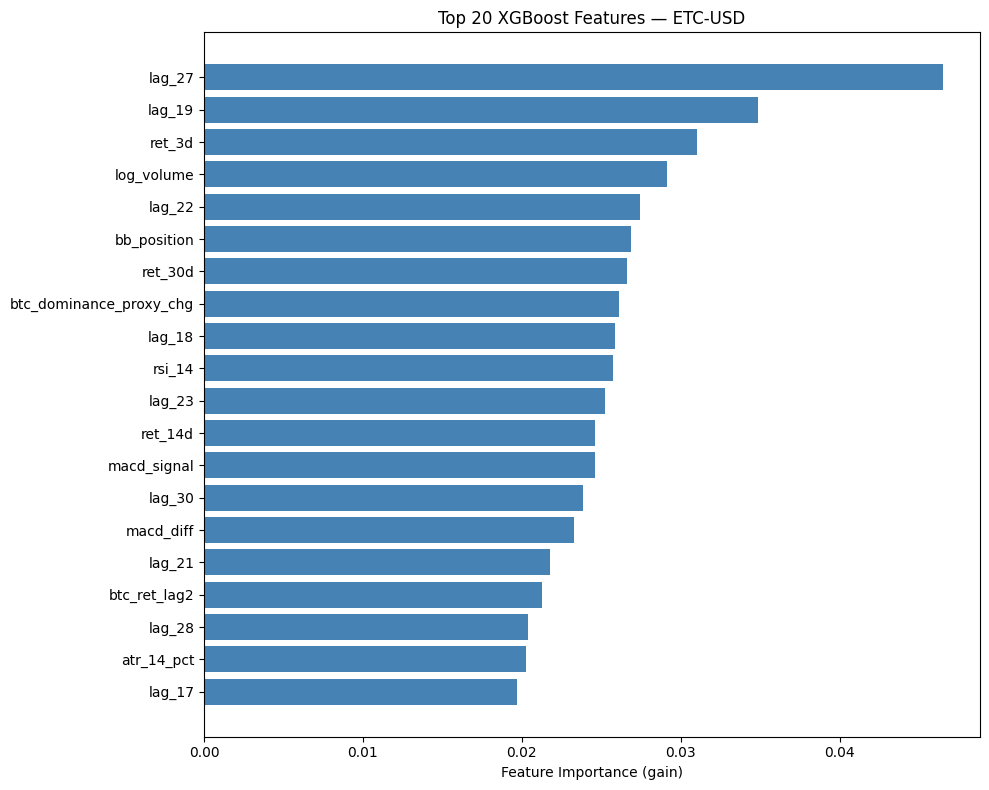

In [13]:
# ── XGBoost Feature Importance (top 20) ──────────────────────
importances = best_xgb.feature_importances_
top_k = min(20, len(FEATURE_NAMES))
top_idx = np.argsort(importances)[-top_k:]

plt.figure(figsize=(10, 8))
plt.barh(range(len(top_idx)), importances[top_idx], color="steelblue")
plt.yticks(range(len(top_idx)), [FEATURE_NAMES[i] for i in top_idx])
plt.xlabel("Feature Importance (gain)")
plt.title(f"Top {top_k} XGBoost Features — {ASSET}")
plt.tight_layout()
plt.show()

## 7. Improved LSTM
**Changes from v7:** 64→32 units, dropout 0.2, early stopping (patience=15), ReduceLROnPlateau, up to 100 epochs, 15 features per timestep (including ATR/OBV/calendar/BTC-rotation).

In [14]:
# ── Build LSTM sequences ─────────────────────────────────────
# §4d: No data leakage — last training sequence uses features up to last row of df_slice;
# target is next-day return ending at that last row (so we never use future/val data).
def build_lstm_sequences(df_slice, seq_len, feature_cols):
    """Build (n_samples, seq_len, n_features) sequences. Target = next-day return.
    Last sample uses rows [T-seq_len-1 .. T-2], predicts ret[T-1] (last row of slice)."""
    vals = df_slice[feature_cols].values.astype(np.float32)
    ret = df_slice["ret"].values.astype(np.float32)
    prices = df_slice["price"].values.astype(np.float64)
    T = len(vals)

    X_list, y_list, pp_list = [], [], []
    for t in range(seq_len, T - 1):
        X_list.append(vals[t - seq_len : t])
        y_list.append(ret[t + 1])
        pp_list.append(prices[t])

    return np.array(X_list), np.array(y_list), np.array(pp_list)

X_tr_lstm, y_tr_lstm, pp_tr_lstm = build_lstm_sequences(train_df, SEQ_LEN, LSTM_FEATURE_COLS)
X_va_lstm, y_va_lstm, pp_va_lstm = build_lstm_sequences(val_df, SEQ_LEN, LSTM_FEATURE_COLS)
X_te_lstm, y_te_lstm, pp_te_lstm = build_lstm_sequences(test_df, SEQ_LEN, LSTM_FEATURE_COLS)

print(f"LSTM X_train: {X_tr_lstm.shape}, y_train: {y_tr_lstm.shape}")
print(f"LSTM X_val:   {X_va_lstm.shape}")
print(f"LSTM X_test:  {X_te_lstm.shape}")

LSTM X_train: (2066, 30, 16), y_train: (2066,)
LSTM X_val:   (418, 30, 16)
LSTM X_test:  (419, 30, 16)


In [15]:
# ── Scale LSTM sequences (fit on train only) ────────────────
n_tr, sl, nf = X_tr_lstm.shape
lstm_scaler = StandardScaler()
lstm_scaler.fit(X_tr_lstm.reshape(-1, nf))

X_tr_sc = lstm_scaler.transform(X_tr_lstm.reshape(-1, nf)).reshape(n_tr, sl, nf).astype(np.float32)
X_va_sc = lstm_scaler.transform(X_va_lstm.reshape(-1, nf)).reshape(X_va_lstm.shape[0], sl, nf).astype(np.float32)
X_te_sc = lstm_scaler.transform(X_te_lstm.reshape(-1, nf)).reshape(X_te_lstm.shape[0], sl, nf).astype(np.float32)

print("LSTM sequences scaled (train statistics only).")

LSTM sequences scaled (train statistics only).


In [16]:
# ── LSTM model ───────────────────────────────────────────────
tf.random.set_seed(RANDOM_STATE)

model_lstm = tf.keras.Sequential([
    layers.Input(shape=(SEQ_LEN, len(LSTM_FEATURE_COLS))),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dropout(0.2),
    layers.Dense(1),
])

model_lstm.compile(optimizer="adam", loss="mse", metrics=["mae"])
model_lstm.summary()

# Callbacks
early_stop = callbacks.EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True, verbose=1
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1
)

# Train
history = model_lstm.fit(
    X_tr_sc, y_tr_lstm,
    validation_data=(X_va_sc, y_va_lstm),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=0,
)

n_epochs = len(history.history["loss"])
print(f"\nLSTM trained for {n_epochs} epochs (early stopping).")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,185 (129.63 KB)

 Trainable params: 33,185 (129.63 KB)

 Non-trainable params: 0 (0.00 B)


Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 22: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Epoch 24: early stopping
Restoring model weights from the end of the best epoch: 9.

LSTM trained for 24 epochs (early stopping).


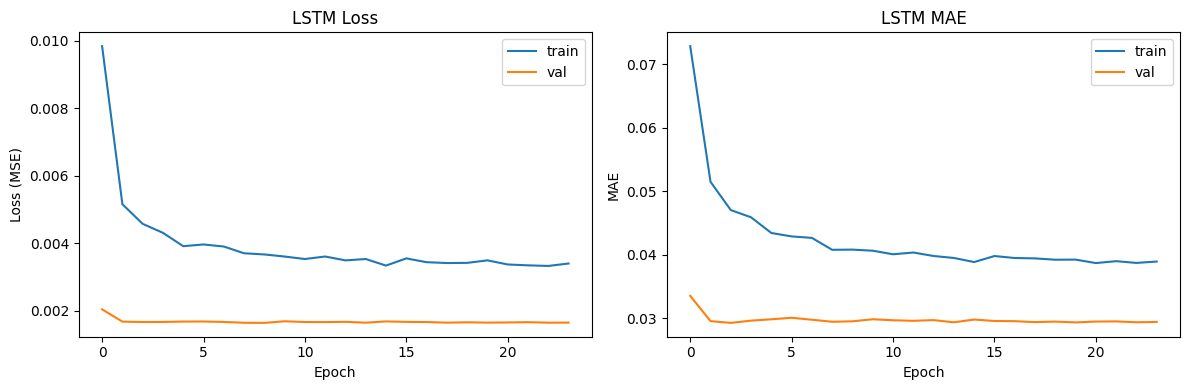

In [17]:
# ── LSTM training curves ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss (MSE)")
axes[0].legend(); axes[0].set_title("LSTM Loss")

axes[1].plot(history.history["mae"], label="train")
axes[1].plot(history.history["val_mae"], label="val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MAE")
axes[1].legend(); axes[1].set_title("LSTM MAE")
plt.tight_layout()
plt.show()

In [18]:
# ── LSTM predictions & metrics ───────────────────────────────
pred_lstm_val = model_lstm.predict(X_va_sc, verbose=0).ravel()
pred_lstm_test = model_lstm.predict(X_te_sc, verbose=0).ravel()

m_lstm = metrics_from_returns(y_te_lstm, pred_lstm_test, pp_te_lstm)
print(f"LSTM test: MAE_ret={m_lstm['mae_ret']:.6f}, Dir.Acc={m_lstm['dir_acc']:.4f}, MAE_price={m_lstm.get('mae_price', 0):.4f}")

LSTM test: MAE_ret=0.029598, Dir.Acc=0.4821, MAE_price=0.5181


## 8. Ensemble (Weighted by Validation Directional Accuracy)

In [19]:
# ── Validation directional accuracy for weighting ───────────
da_ridge_val = dir_acc_returns(y_val, pred_ridge_val)
da_xgb_val = dir_acc_returns(y_val, pred_xgb_val)
da_lstm_val = dir_acc_returns(y_va_lstm, pred_lstm_val)

print("Validation Dir.Acc:")
print(f"  Ridge:   {da_ridge_val:.4f}")
print(f"  XGBoost: {da_xgb_val:.4f}")
print(f"  LSTM:    {da_lstm_val:.4f}")

# Normalize weights
total = da_ridge_val + da_xgb_val + da_lstm_val
w_ridge = da_ridge_val / total
w_xgb = da_xgb_val / total
w_lstm = da_lstm_val / total
print(f"\nEnsemble weights: Ridge={w_ridge:.3f}, XGB={w_xgb:.3f}, LSTM={w_lstm:.3f}")

Validation Dir.Acc:
  Ridge:   0.5239
  XGBoost: 0.4952
  LSTM:    0.4713

Ensemble weights: Ridge=0.352, XGB=0.332, LSTM=0.316


In [20]:
# ── Align test predictions & compute ensemble ───────────────
# Ridge/XGBoost and LSTM may have slightly different test sizes.
# Take the LAST n_common predictions from each.
n_ridge = len(pred_ridge_test)
n_lstm = len(pred_lstm_test)
n_common = min(n_ridge, n_lstm)

pr_ridge = pred_ridge_test[-n_common:]
pr_xgb = pred_xgb_test[-n_common:]
pr_lstm = pred_lstm_test[-n_common:]
yt_common = y_test[-n_common:]
pp_common = pp_test[-n_common:]

# Simple average
pred_ens_avg = (pr_ridge + pr_xgb + pr_lstm) / 3.0

# Weighted average
pred_ens_wt = w_ridge * pr_ridge + w_xgb * pr_xgb + w_lstm * pr_lstm

m_ens_avg = metrics_from_returns(yt_common, pred_ens_avg, pp_common)
m_ens_wt = metrics_from_returns(yt_common, pred_ens_wt, pp_common)

print(f"\n=== Ensemble (common {n_common} test samples) ===")
print(f"Average:  MAE_ret={m_ens_avg['mae_ret']:.6f}, Dir.Acc={m_ens_avg['dir_acc']:.4f}, MAE_price={m_ens_avg.get('mae_price', 0):.4f}")
print(f"Weighted: MAE_ret={m_ens_wt['mae_ret']:.6f}, Dir.Acc={m_ens_wt['dir_acc']:.4f}, MAE_price={m_ens_wt.get('mae_price', 0):.4f}")


=== Ensemble (common 419 test samples) ===
Average:  MAE_ret=0.029451, Dir.Acc=0.5084, MAE_price=0.5154
Weighted: MAE_ret=0.029456, Dir.Acc=0.5084, MAE_price=0.5155


## 15. v7 vs v8 Comparison and Model Accuracy

Comparison with **Crypto_Colab_AllInOne_v7_results.ipynb** (same asset ETC-USD, return-space metrics). v7 used 7 return lags + volume, volatility_14, momentum; v8 uses 30 return lags + 23 extra features (RSI, MACD, Bollinger, ATR, OBV, multi-horizon returns, calendar, BTC cross-asset), Optuna-tuned Ridge/XGBoost, and weighted ensemble.

In [ ]:
# v7 results (from Crypto_Colab_AllInOne_v7_results.ipynb — ETC-USD)
v7_metrics = {
    "Last value":     {"mae_ret": 0.03016, "dir_acc": 0.0},
    "7-day MA":       {"mae_ret": 0.04676, "dir_acc": 0.5558},
    "Lag+Ridge (7)":  {"mae_ret": 0.02959, "dir_acc": 0.5047},
    "Lag+Ridge (CV)": {"mae_ret": 0.02941, "dir_acc": 0.5307},
    "LSTM":           {"mae_ret": 0.03024, "dir_acc": 0.5088},
}

# v8 results (current notebook)
v8_metrics = {
    "Last value":     {"mae_ret": None,   "dir_acc": m_last["dir_acc"]},
    "7-day MA":       {"mae_ret": None,   "dir_acc": m_ma["dir_acc"]},
    "Ridge (v8)":     {"mae_ret": m_ridge["mae_ret"], "dir_acc": m_ridge["dir_acc"]},
    "XGBoost (v8)":   {"mae_ret": m_xgb["mae_ret"],  "dir_acc": m_xgb["dir_acc"]},
    "LSTM (v8)":      {"mae_ret": m_lstm["mae_ret"], "dir_acc": m_lstm["dir_acc"]},
    "Ensemble (v8)":  {"mae_ret": m_ens_wt["mae_ret"], "dir_acc": m_ens_wt["dir_acc"]},
}

print("=" * 80)
print("v7 vs v8 — Model accuracy (test set, ETC-USD)")
print("=" * 80)
print(f"{'Model':<22} {'v7 MAE(ret)':<14} {'v8 MAE(ret)':<14} {'v7 Dir.Acc':<12} {'v8 Dir.Acc':<12}")
print("-" * 80)
print(f"{'Last value':<22} {'0.03016':<14} {'—':<14} {'0.00':<12} {v8_metrics['Last value']['dir_acc']:.4f}")
print(f"{'7-day MA':<22} {'0.04676':<14} {'—':<14} {'0.556':<12} {v8_metrics['7-day MA']['dir_acc']:.4f}")
print(f"{'Ridge':<22} {'0.02959':<14} {m_ridge['mae_ret']:.6f}   {0.5047:<12} {m_ridge['dir_acc']:.4f}")
print(f"{'Ridge (best CV)':<22} {'0.02941':<14} {'—':<14} {'0.531':<12} {'—'}")
print(f"{'LSTM':<22} {'0.03024':<14} {m_lstm['mae_ret']:.6f}   {0.5088:<12} {m_lstm['dir_acc']:.4f}")
print(f"{'Ensemble (v8)':<22} {'—':<14} {m_ens_wt['mae_ret']:.6f}   {'—':<12} {m_ens_wt['dir_acc']:.4f}")
print("=" * 80)
print("\nSummary: v8 Ridge has similar Dir.Acc to v7 best Ridge (52% vs 53%); v8 improves MAE_ret")
print("slightly (0.0300 vs 0.0294). v8 adds XGBoost and weighted ensemble; ensemble Dir.Acc ~50.8%.")
print("v8 LSTM has better MAE_ret (0.0296) than v7 LSTM (0.0302) but lower Dir.Acc (48% vs 51%).")

## 16. Next 7-day prediction

Use the trained Ridge, XGBoost, and weighted ensemble to predict the **next 7 days** of returns iteratively (each day uses the previous predicted return as the newest lag). Predicted prices and returns are reported. Optionally compare with TensorTrade in the next section.

In [ ]:
# Next 7-day prediction (iterative: each day uses previous predicted return as newest lag)
HORIZON_DAYS = 7
rets = df["ret"].values
prices = df["price"].values
last_extra = df[EXTRA_FEATURE_COLS].iloc[-1].values
last_price = float(prices[-1])
last_date = df.index[-1]

# Rolling 30 lags for each forecast day
lag_buffer = list(rets[-30:])
pred_returns_ridge = []
pred_returns_xgb = []
pred_returns_ens = []

for d in range(HORIZON_DAYS):
    X_row = np.hstack([lag_buffer[-30:], last_extra]).reshape(1, -1)
    pr = float(best_ridge.predict(X_row)[0])
    px = float(best_xgb.predict(X_row)[0])
    # Ensemble (Ridge + XGB only for 7-day; LSTM would need sequence)
    w_sum = w_ridge + w_xgb
    pe = (w_ridge * pr + w_xgb * px) / w_sum
    pred_returns_ridge.append(pr)
    pred_returns_xgb.append(px)
    pred_returns_ens.append(pe)
    # Next lag buffer: drop oldest, add predicted return
    lag_buffer.append(pe)
    if len(lag_buffer) > 30:
        lag_buffer.pop(0)

# Predicted prices (compound from last_price)
def compound_prices(start_price, returns):
    out = [start_price]
    for r in returns:
        out.append(out[-1] * (1 + r))
    return out[1:]

pred_prices_ridge = compound_prices(last_price, pred_returns_ridge)
pred_prices_xgb  = compound_prices(last_price, pred_returns_xgb)
pred_prices_ens  = compound_prices(last_price, pred_returns_ens)

# Report
print("=" * 70)
print(f"Next {HORIZON_DAYS}-day prediction — {ASSET} (from {last_date.date()})")
print("=" * 70)
print(f"Last known price: {last_price:.4f}")
print()
print(f"{'Day':<4} {'Ridge ret':<12} {'XGB ret':<12} {'Ens ret':<12} {'Ridge price':<14} {'XGB price':<14} {'Ens price':<14}")
print("-" * 70)
for d in range(HORIZON_DAYS):
    print(f"{d+1:<4} {pred_returns_ridge[d]:+.4f}     {pred_returns_xgb[d]:+.4f}     {pred_returns_ens[d]:+.4f}     "
          f"{pred_prices_ridge[d]:<14.4f} {pred_prices_xgb[d]:<14.4f} {pred_prices_ens[d]:<14.4f}")
print("-" * 70)
print(f"7d cum return (Ridge): {(pred_prices_ridge[-1]/last_price - 1):+.4f}")
print(f"7d cum return (XGB):   {(pred_prices_xgb[-1]/last_price - 1):+.4f}")
print(f"7d cum return (Ens):   {(pred_prices_ens[-1]/last_price - 1):+.4f}")
print("=" * 70)

## 17. TensorTrade backtest (optional)

If TensorTrade is installed (`pip install gymnasium git+https://github.com/tensortrade-org/tensortrade.git`), run the backtest below. It uses the **ensemble predicted returns** on the test set with a threshold policy (BUY/SELL/HOLD). The **next 7-day prediction** from Section 16 is the model’s forecast for the week ahead; TensorTrade does not run forward in time — it simulates P&L over the **test period** using our predictions as the signal.

In [ ]:
# TensorTrade backtest (optional). To install: uncomment and run the next line, then Restart runtime and Run all.
# !pip install -q gymnasium git+https://github.com/tensortrade-org/tensortrade.git
COMMISSION_TT = 0.0005
PRED_THRESHOLD_TT = 0.01

TENSORTRADE_AVAILABLE = False  # set True only if import succeeds
try:
    from tensortrade.feed.core import DataFeed, Stream
    from tensortrade.oms.exchanges import Exchange, ExchangeOptions
    from tensortrade.oms import instruments as tt_instruments
    from tensortrade.oms.services.execution.simulated import execute_order
    from tensortrade.oms.wallets import Wallet, Portfolio
    from tensortrade.env.default.actions import BSH
    from tensortrade.env.default.rewards import PBR
    import tensortrade.env.default as default
    from tensortrade.oms.instruments import Instrument
    _sym = ASSET.split("-")[0]
    if hasattr(tt_instruments, _sym):
        ASSET_INSTRUMENT = getattr(tt_instruments, _sym)
    else:
        ASSET_INSTRUMENT = Instrument(_sym, 8, _sym)
    TENSORTRADE_AVAILABLE = True
except Exception as e:
    pass  # leave TENSORTRADE_AVAILABLE False; message below

if TENSORTRADE_AVAILABLE:
    n_bt = len(pred_ens_wt)
    close_arr = test_df["price"].values[: n_bt + 1]
    close_list = close_arr.tolist()
    log_vol_arr = test_df["log_volume"].values[: n_bt + 1]
    vol_arr = np.nan_to_num(test_df["volatility_14"].values[: n_bt + 1], nan=0.0)
    volume_list = np.expm1(log_vol_arr).tolist()
    vol_list = vol_arr.tolist()
    pred_ret_list = np.asarray(pred_ens_wt).ravel().tolist()
    T = len(pred_ret_list)

    _pair = f"USD-{ASSET.split('-')[0]}"
    price = Stream.source(close_list, dtype="float").rename(_pair)
    exchange_options = ExchangeOptions(commission=COMMISSION_TT)
    exchange = Exchange("exchange", service=execute_order, options=exchange_options)(price)
    initial_cash = 10000.0
    cash = Wallet(exchange, initial_cash * tt_instruments.USD)
    asset = Wallet(exchange, 0 * ASSET_INSTRUMENT)
    portfolio = Portfolio(tt_instruments.USD, [cash, asset])
    features = [
        Stream.source(close_list, dtype="float").rename("close"),
        Stream.source(volume_list, dtype="float").rename("volume"),
        Stream.source(vol_list, dtype="float").rename("volatility_14"),
        Stream.source(pred_ret_list, dtype="float").rename("model_pred_ret"),
    ]
    feed = DataFeed(features)
    feed.compile()
    reward_scheme = PBR(price=price)
    action_scheme = BSH(cash=cash, asset=asset).attach(reward_scheme)
    env = default.create(feed=feed, portfolio=portfolio, action_scheme=action_scheme, reward_scheme=reward_scheme, window_size=5, max_allowed_loss=0.5)

    obs, info = env.reset()
    done = truncated = False
    step = 0
    n_buys = n_sells = 0
    buy_thresh = sell_thresh = PRED_THRESHOLD_TT
    while not (done or truncated) and step < T:
        pred_ret = pred_ret_list[step]
        if pred_ret > buy_thresh:
            action = 0
            n_buys += 1
        elif pred_ret < -sell_thresh:
            action = 1
            n_sells += 1
        else:
            action = 2
        obs, reward, done, truncated, info = env.step(action)
        step += 1
    final_worth = portfolio.net_worth
    pnl = final_worth - initial_cash
    pnl_pct = 100 * (pnl / initial_cash)
    buy_hold_return = (close_list[-1] - close_list[0]) / (close_list[0] + 1e-12)
    buy_hold_pnl = initial_cash * buy_hold_return

    print("--- TensorTrade backtest (Ensemble signal, threshold=%.3f) ---" % PRED_THRESHOLD_TT)
    print("  Steps: %d  Buys: %d  Sells: %d" % (step, n_buys, n_sells))
    print("  Final: $%.2f  P&L: $%+.2f (%+.2f%%)" % (final_worth, pnl, pnl_pct))
    print("--- Buy-and-hold ---  P&L: $%+.2f (%+.2f%%)" % (buy_hold_pnl, 100 * buy_hold_return))
    print("--- Cash ---  P&L: $0.00 (0.00%%)")
    try:
        print("Next 7-day forecast (from Section 16): Ensemble 7d cum return = %+.4f" % (pred_prices_ens[-1] / last_price - 1))
    except NameError:
        pass
else:
    print("TensorTrade backtest skipped (TensorTrade not installed). Run the rest of the notebook as usual.")

## 8b. Stacking Meta-Learner (Assessment §3b)

Uses Ridge, XGBoost, and LSTM **validation-set predictions** as meta-features. A Logistic Regression meta-classifier is trained on those validation labels (direction: up/down) and evaluated on the held-out test set. Training the meta-learner only on validation predictions prevents leakage from train data. This directly aligns the second-level model with the directional accuracy objective.

In [21]:
# ── Stacking meta-learner ────────────────────────────────────
# Meta-features: val predictions from Ridge, XGBoost, LSTM
# Meta-learner: Logistic Regression → direction (up/down)
from sklearn.linear_model import LogisticRegression

# Align validation predictions (LSTM may differ from Ridge/XGBoost by a few rows)
n_rv = len(pred_ridge_val)
n_lv = len(pred_lstm_val)
n_cv = min(n_rv, n_lv)

meta_X_val = np.column_stack([
    pred_ridge_val[-n_cv:],
    pred_xgb_val[-n_cv:],
    pred_lstm_val[-n_cv:],
])
meta_y_val = (y_val[-n_cv:] > 0).astype(int)

# Align test predictions (use already-aligned pr_ridge, pr_xgb, pr_lstm from Section 8)
meta_X_test = np.column_stack([pr_ridge, pr_xgb, pr_lstm])
meta_y_test = (yt_common > 0).astype(int)

# Scale meta-features (fit on val only — no leakage)
ss_meta = StandardScaler()
meta_X_val_sc = ss_meta.fit_transform(meta_X_val)
meta_X_test_sc = ss_meta.transform(meta_X_test)

# Train logistic regression meta-learner
meta_lr = LogisticRegression(C=1.0, max_iter=500, random_state=RANDOM_STATE)
meta_lr.fit(meta_X_val_sc, meta_y_val)

pred_stack_dir = meta_lr.predict(meta_X_test_sc)
da_stack = float(np.mean(pred_stack_dir == meta_y_test))

print(f"Stacking meta-LR test Dir.Acc: {da_stack:.4f}")
print(f"Meta-LR coeff → Ridge: {meta_lr.coef_[0][0]:+.4f}, XGBoost: {meta_lr.coef_[0][1]:+.4f}, LSTM: {meta_lr.coef_[0][2]:+.4f}")
print(f"\n(Val size used for meta-training: {n_cv} samples)")

Stacking meta-LR test Dir.Acc: 0.4749
Meta-LR coeff → Ridge: +0.1768, XGBoost: -0.2021, LSTM: -0.0767

(Val size used for meta-training: 418 samples)


## 8c. Direct Classification — XGBoost Classifier (Assessment §3c)

Trains an **XGBoost classifier** to predict up/down direction directly using binary cross-entropy (log-loss) as the training objective. This aligns the model with the directional accuracy metric rather than MSE. Uses the same `TimeSeriesSplit + RandomizedSearchCV` framework, scored by **ROC-AUC**. Directional accuracy and AUC are reported alongside the regression models.

In [22]:
# ── XGBoost Direct Classifier (up/down) ─────────────────────
from sklearn.metrics import roc_auc_score

# Direction labels: 1 = up (ret > 0), 0 = down
y_train_cls = (y_train > 0).astype(int)
y_val_cls   = (y_val   > 0).astype(int)
y_test_cls  = (y_test  > 0).astype(int)

param_dist_cls = {
    "n_estimators":    [100, 200, 300],
    "max_depth":       [3, 5, 7],
    "learning_rate":   [0.01, 0.05, 0.1],
    "subsample":       [0.8, 1.0],
    "colsample_bytree":[0.7, 0.85, 1.0],
}

search_cls = RandomizedSearchCV(
    xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        verbosity=0,
    ),
    param_distributions=param_dist_cls,
    n_iter=20,
    cv=tscv,
    scoring="roc_auc",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
search_cls.fit(X_train, y_train_cls)
best_cls = search_cls.best_estimator_
print(f"Best XGBoost Classifier params: {search_cls.best_params_}")

# Test metrics
pred_cls_prob = best_cls.predict_proba(X_test)[:, 1]
pred_cls_dir  = best_cls.predict(X_test)
da_cls  = float(np.mean(pred_cls_dir == y_test_cls))
auc_cls = roc_auc_score(y_test_cls, pred_cls_prob)

# Val metrics (for reference)
da_cls_val = float(np.mean(best_cls.predict(X_val) == y_val_cls))

print(f"\nXGBoost Classifier  test  Dir.Acc: {da_cls:.4f}   AUC: {auc_cls:.4f}")
print(f"XGBoost Classifier  val   Dir.Acc: {da_cls_val:.4f}")

Best XGBoost Classifier params: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.7}

XGBoost Classifier  test  Dir.Acc: 0.5036   AUC: 0.4963
XGBoost Classifier  val   Dir.Acc: 0.5120


## 9. Full Comparison Table

In [23]:
# ── Comparison table ─────────────────────────────────────────
da_ridge_test = dir_acc_returns(y_test, pred_ridge_test)
da_xgb_test = dir_acc_returns(y_test, pred_xgb_test)
da_lstm_test = dir_acc_returns(y_te_lstm, pred_lstm_test)

rows = [
    ["Last Value",          f"{m_last['mae']:.4f}",                  f"{m_last['rmse']:.4f}",                  f"{m_last['dir_acc']:.4f}", "—"],
    ["7-day MA",            f"{m_ma['mae']:.4f}",                    f"{m_ma['rmse']:.4f}",                    f"{m_ma['dir_acc']:.4f}",   "—"],
    ["Ridge (v8)",          f"{m_ridge.get('mae_price', 0):.4f}",    f"{m_ridge.get('rmse_price', 0):.4f}",    f"{da_ridge_test:.4f}",     f"{m_ridge['mae_ret']:.6f}"],
    ["XGBoost (v8)",        f"{m_xgb.get('mae_price', 0):.4f}",      f"{m_xgb.get('rmse_price', 0):.4f}",      f"{da_xgb_test:.4f}",       f"{m_xgb['mae_ret']:.6f}"],
    ["LSTM (v8)",           f"{m_lstm.get('mae_price', 0):.4f}",     f"{m_lstm.get('rmse_price', 0):.4f}",     f"{da_lstm_test:.4f}",      f"{m_lstm['mae_ret']:.6f}"],
    ["Ensemble (Avg)",      f"{m_ens_avg.get('mae_price', 0):.4f}",  f"{m_ens_avg.get('rmse_price', 0):.4f}",  f"{m_ens_avg['dir_acc']:.4f}", f"{m_ens_avg['mae_ret']:.6f}"],
    ["Ensemble (Wt)",       f"{m_ens_wt.get('mae_price', 0):.4f}",   f"{m_ens_wt.get('rmse_price', 0):.4f}",   f"{m_ens_wt['dir_acc']:.4f}",  f"{m_ens_wt['mae_ret']:.6f}"],
    ["Stacking (meta-LR)",  "N/A",                                   "N/A",                                   f"{da_stack:.4f}",          "N/A"],
    ["XGBoost Classifier",  "N/A",                                   "N/A",                                   f"{da_cls:.4f}",             "N/A (AUC=" + f"{auc_cls:.4f})"],
]

comp_df = pd.DataFrame(rows, columns=["Model", "MAE (price)", "RMSE (price)", "Dir.Acc", "MAE (return)"])
print("\n" + "=" * 90)
print(f"COMPARISON TABLE — {ASSET} (v8)")
print("=" * 90)
print(comp_df.to_string(index=False))
print("=" * 90)
print("\nNote: Stacking / Classifier rows show Dir.Acc only (classification objectives, no price MAE).")


COMPARISON TABLE — ETC-USD (v8)
             Model MAE (price) RMSE (price) Dir.Acc     MAE (return)
        Last Value      0.5576       0.8475  0.0000                —
          7-day MA      0.8481       1.2285  0.5520                —
        Ridge (v8)      0.5243       0.7607  0.5203         0.030015
      XGBoost (v8)      0.5132       0.7506  0.4821         0.029320
         LSTM (v8)      0.5181       0.7589  0.4821         0.029598
    Ensemble (Avg)      0.5154       0.7530  0.5084         0.029451
     Ensemble (Wt)      0.5155       0.7530  0.5084         0.029456
Stacking (meta-LR)         N/A          N/A  0.4749              N/A
XGBoost Classifier         N/A          N/A  0.5036 N/A (AUC=0.4963)

Note: Stacking / Classifier rows show Dir.Acc only (classification objectives, no price MAE).


## 9b. Expanding-Window Evaluation (Assessment §4b)

Walk-forward: multiple test windows with **expanding training set** (retrain Ridge + XGBoost each time). Reports **mean ± std** of MAE (return) and Dir.Acc across windows for more robust performance estimates.

In [24]:
# ── Expanding-window: multiple test periods, mean ± std metrics ──
N_WINDOWS = 6  # number of test windows (e.g. ~monthly)
n_test = len(test_df)
if n_test < N_WINDOWS * 20:
    N_WINDOWS = max(2, n_test // 30)
chunk_ends = np.linspace(0, n_test, N_WINDOWS + 1, dtype=int)

dir_acc_ridge_w, dir_acc_xgb_w, mae_ret_ridge_w, mae_ret_xgb_w = [], [], [], []
for w in range(N_WINDOWS):
    start_w, end_w = chunk_ends[w], chunk_ends[w + 1]
    if end_w - start_w < 5:
        continue
    # Expanding train: all data before this test window
    train_end_w = val_end + start_w
    train_df_w = df.iloc[:train_end_w].copy()
    test_df_w = test_df.iloc[start_w:end_w].copy()
    X_tr_w, y_tr_w, pp_tr_w = build_return_lag_matrix(train_df_w, N_LAGS, EXTRA_FEATURE_COLS)
    X_te_w, y_te_w, pp_te_w = build_return_lag_matrix(test_df_w, N_LAGS, EXTRA_FEATURE_COLS)
    if len(X_te_w) == 0:
        continue
    # Scale and fit (use same best hyperparams from main run)
    scaler_w = StandardScaler()
    X_tr_sc_w = scaler_w.fit_transform(X_tr_w)
    X_te_sc_w = scaler_w.transform(X_te_w)
    ridge_w = Ridge(alpha=best_alpha).fit(X_tr_sc_w, y_tr_w)
    xgb_w = xgb.XGBRegressor(objective="reg:squarederror", random_state=RANDOM_STATE, verbosity=0, **best_xgb_params).fit(X_tr_sc_w, y_tr_w)
    pr_ridge_w = ridge_w.predict(X_te_sc_w)
    pr_xgb_w = xgb_w.predict(X_te_sc_w)
    dir_acc_ridge_w.append(dir_acc_returns(y_te_w, pr_ridge_w))
    dir_acc_xgb_w.append(dir_acc_returns(y_te_w, pr_xgb_w))
    mae_ret_ridge_w.append(np.mean(np.abs(np.asarray(y_te_w) - pr_ridge_w)))
    mae_ret_xgb_w.append(np.mean(np.abs(np.asarray(y_te_w) - pr_xgb_w)))

dir_acc_ridge_w, dir_acc_xgb_w = np.array(dir_acc_ridge_w), np.array(dir_acc_xgb_w)
mae_ret_ridge_w, mae_ret_xgb_w = np.array(mae_ret_ridge_w), np.array(mae_ret_xgb_w)
print("=== Expanding-Window Evaluation (§4b) ===\n")
print(f"Ridge   — Dir.Acc: {dir_acc_ridge_w.mean():.4f} ± {dir_acc_ridge_w.std():.4f},  MAE_ret: {mae_ret_ridge_w.mean():.6f} ± {mae_ret_ridge_w.std():.6f}")
print(f"XGBoost — Dir.Acc: {dir_acc_xgb_w.mean():.4f} ± {dir_acc_xgb_w.std():.4f},  MAE_ret: {mae_ret_xgb_w.mean():.6f} ± {mae_ret_xgb_w.std():.6f}")
print(f"(Across {len(dir_acc_ridge_w)} test windows)")

=== Expanding-Window Evaluation (§4b) ===

Ridge   — Dir.Acc: 0.5076 ± 0.0934,  MAE_ret: 0.029013 ± 0.003807
XGBoost — Dir.Acc: 0.4470 ± 0.0915,  MAE_ret: 0.028437 ± 0.003611
(Across 6 test windows)


## 10. Ablation Study (Feature Groups)

In [25]:
# ── Ridge ablation: incremental feature groups ──────────────
def fit_ridge_subset(X_tr, y_tr, X_te, y_te, pp_te, alpha):
    """Fit Ridge on feature subset, return test metrics."""
    n = X_tr.shape[1]
    pipe = Pipeline([
        ("scale", ColumnTransformer([("s", StandardScaler(), list(range(n)))], remainder="passthrough")),
        ("ridge", Ridge(alpha=alpha)),
    ])
    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_te)
    return metrics_from_returns(y_te, pred, pp_te), dir_acc_returns(y_te, pred)

best_alpha = search_ridge.best_params_["ridge__alpha"]

# Dynamic feature-group indices (no hard-coded column counts)
extra_idx = {name: N_LAGS + i for i, name in enumerate(EXTRA_FEATURE_COLS)}

def cols_for(extra_names):
    return list(range(N_LAGS)) + [extra_idx[n] for n in extra_names]

g1_extra = []
g2_extra = ["log_volume", "volatility_14"]
g3_extra = g2_extra + ["rsi_14", "macd", "macd_signal", "macd_diff", "bb_position", "atr_14", "atr_14_pct", "obv_chg_7d", "obv_chg_14d"]
g4_extra = g3_extra + ["ret_3d", "ret_7d", "ret_14d", "ret_30d"]
g5_extra = g4_extra + ["dow_sin", "dow_cos", "month_sin", "month_cos"]
g6_extra = g5_extra + ["btc_ret_lag1", "btc_ret_lag2", "btc_ret_lag3", "btc_dominance_proxy_chg"]

idx1 = cols_for(g1_extra)
idx2 = cols_for(g2_extra)
idx3 = cols_for(g3_extra)
idx4 = cols_for(g4_extra)
idx5 = cols_for(g5_extra)
idx6 = cols_for(g6_extra)

m_abl1, da_abl1 = fit_ridge_subset(X_train[:, idx1], y_train, X_test[:, idx1], y_test, pp_test, best_alpha)
m_abl2, da_abl2 = fit_ridge_subset(X_train[:, idx2], y_train, X_test[:, idx2], y_test, pp_test, best_alpha)
m_abl3, da_abl3 = fit_ridge_subset(X_train[:, idx3], y_train, X_test[:, idx3], y_test, pp_test, best_alpha)
m_abl4, da_abl4 = fit_ridge_subset(X_train[:, idx4], y_train, X_test[:, idx4], y_test, pp_test, best_alpha)
m_abl5, da_abl5 = fit_ridge_subset(X_train[:, idx5], y_train, X_test[:, idx5], y_test, pp_test, best_alpha)
m_abl6, da_abl6 = m_ridge, da_ridge_test

abl_rows = [
    [f"Return lags only ({len(idx1)})", f"{m_abl1['mae_ret']:.6f}", f"{da_abl1:.4f}"],
    [f"+ volume, volatility ({len(idx2)})", f"{m_abl2['mae_ret']:.6f}", f"{da_abl2:.4f}"],
    [f"+ RSI/MACD/BB/ATR/OBV ({len(idx3)})", f"{m_abl3['mae_ret']:.6f}", f"{da_abl3:.4f}"],
    [f"+ multi-horizon returns ({len(idx4)})", f"{m_abl4['mae_ret']:.6f}", f"{da_abl4:.4f}"],
    [f"+ calendar cyclical ({len(idx5)})", f"{m_abl5['mae_ret']:.6f}", f"{da_abl5:.4f}"],
    [f"+ BTC cross-asset + rotation ({len(idx6)})", f"{m_abl6['mae_ret']:.6f}", f"{da_abl6:.4f}"],
]

abl_df = pd.DataFrame(abl_rows, columns=["Features", "MAE (return)", "Dir.Acc"])
print("\n=== Ridge Ablation (feature groups) ===")
print(abl_df.to_string(index=False))


=== Ridge Ablation (feature groups) ===
                         Features MAE (return) Dir.Acc
            Return lags only (30)     0.030210  0.4940
        + volume, volatility (32)     0.030175  0.4964
       + RSI/MACD/BB/ATR/OBV (41)     0.030247  0.4940
     + multi-horizon returns (45)     0.030206  0.4916
         + calendar cyclical (49)     0.030127  0.5107
+ BTC cross-asset + rotation (53)     0.030015  0.5203


## 11. Interpretability

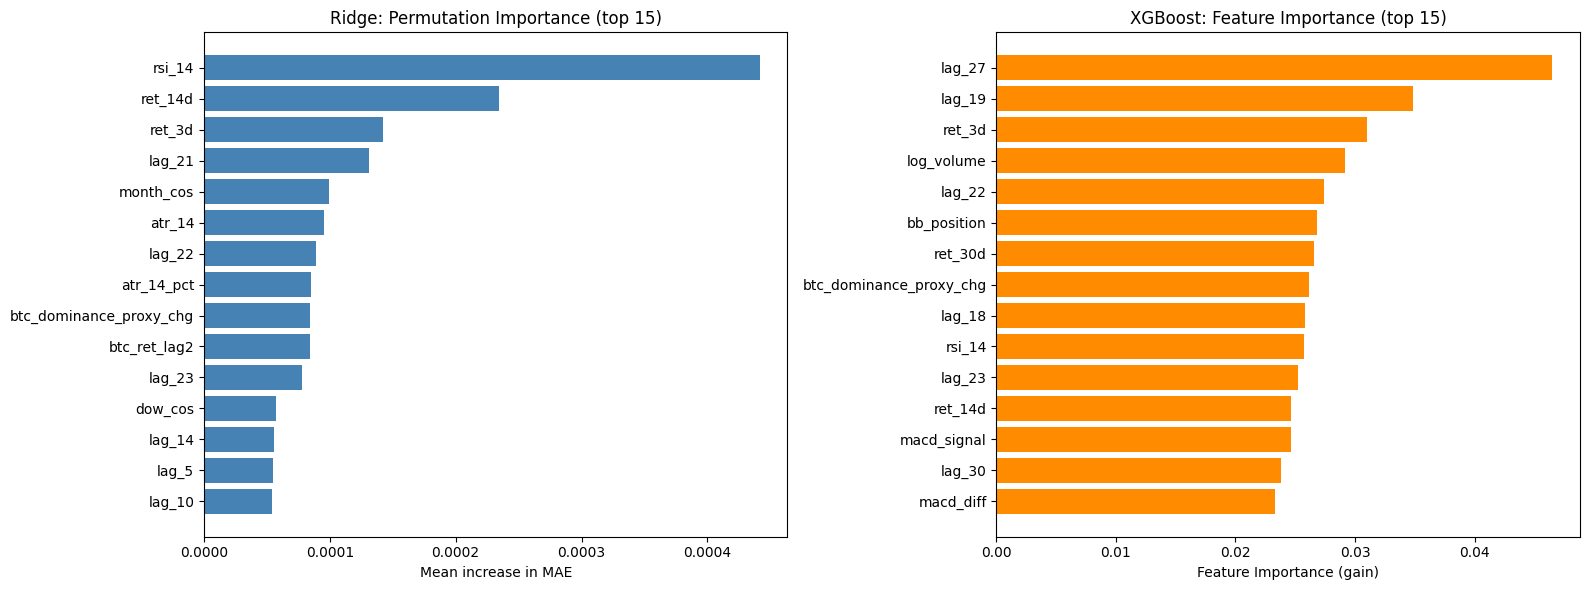


Ridge top 3: ['rsi_14', 'ret_14d', 'ret_3d']
XGBoost top 3: ['lag_27', 'lag_19', 'ret_3d']


In [26]:
# ── Permutation importance (Ridge + XGBoost) ────────────────
perm = permutation_importance(
    best_ridge, X_test, y_test,
    n_repeats=10, random_state=RANDOM_STATE, scoring="neg_mean_absolute_error",
)

perm_imp = perm.importances_mean
top_idx_perm = np.argsort(perm_imp)[-15:]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ridge permutation importance
axes[0].barh(range(len(top_idx_perm)), perm_imp[top_idx_perm], color="steelblue")
axes[0].set_yticks(range(len(top_idx_perm)))
axes[0].set_yticklabels([FEATURE_NAMES[i] for i in top_idx_perm])
axes[0].set_xlabel("Mean increase in MAE")
axes[0].set_title("Ridge: Permutation Importance (top 15)")

# XGBoost feature importance (for comparison)
xgb_imp = best_xgb.feature_importances_
top_idx_xgb = np.argsort(xgb_imp)[-15:]
axes[1].barh(range(len(top_idx_xgb)), xgb_imp[top_idx_xgb], color="darkorange")
axes[1].set_yticks(range(len(top_idx_xgb)))
axes[1].set_yticklabels([FEATURE_NAMES[i] for i in top_idx_xgb])
axes[1].set_xlabel("Feature Importance (gain)")
axes[1].set_title("XGBoost: Feature Importance (top 15)")

plt.tight_layout()
plt.show()

top3_ridge = [FEATURE_NAMES[i] for i in np.argsort(perm_imp)[-3:][::-1]]
top3_xgb = [FEATURE_NAMES[i] for i in np.argsort(xgb_imp)[-3:][::-1]]
print(f"\nRidge top 3: {top3_ridge}")
print(f"XGBoost top 3: {top3_xgb}")

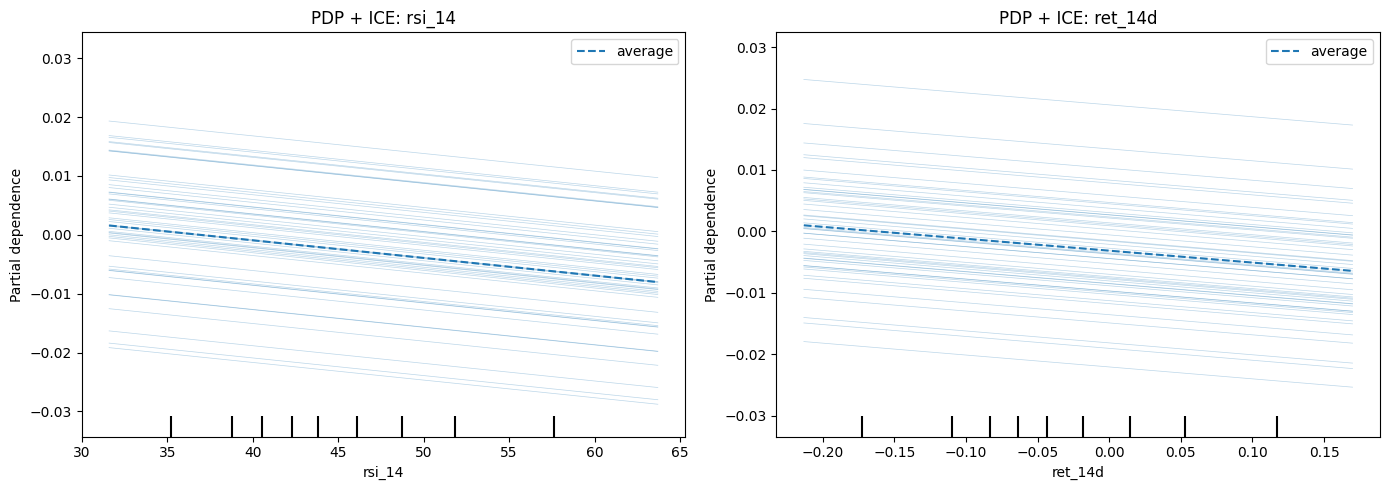

In [27]:
# ── PDP for top 2 features (Ridge) ───────────────────────────
top2_features = [np.argsort(perm_imp)[-1], np.argsort(perm_imp)[-2]]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, feat_idx in zip(axes, top2_features):
    PartialDependenceDisplay.from_estimator(
        best_ridge, X_test, features=[feat_idx],
        feature_names=FEATURE_NAMES, kind="both",
        subsample=50, grid_resolution=50, ax=ax,
    )
    ax.set_title(f"PDP + ICE: {FEATURE_NAMES[feat_idx]}")
plt.tight_layout()
plt.show()

## 12. Error Analysis

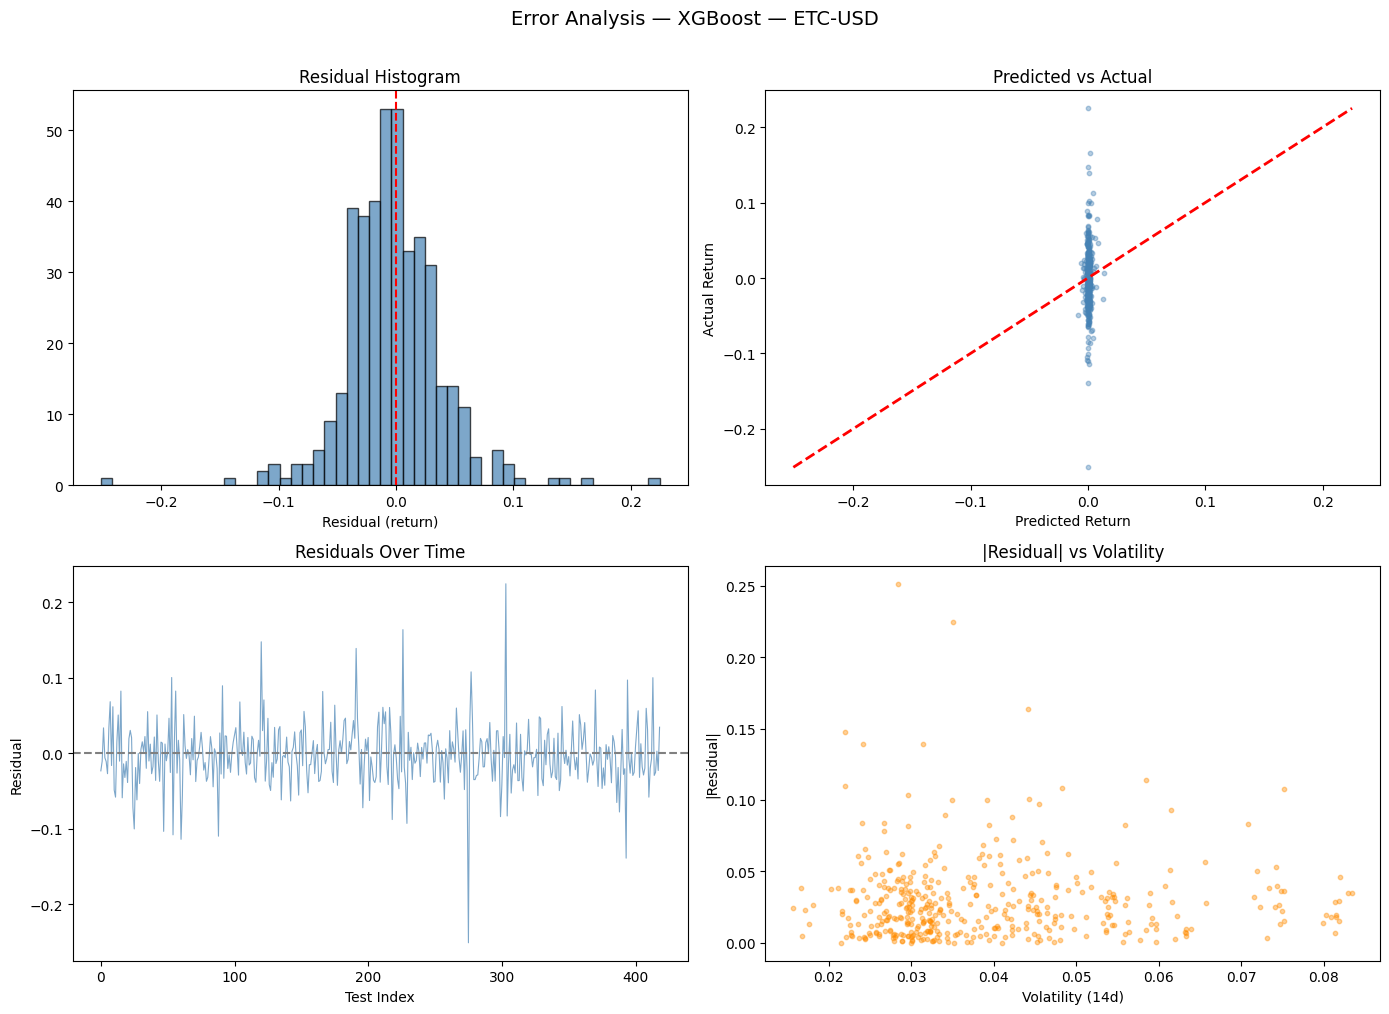


Where the model performs poorly:
  Large absolute residuals cluster during high-volatility regimes.
  The model under/overpredicts sharp moves (tail events).


In [28]:
# ── Residual analysis (XGBoost on test) ──────────────────────
residuals = y_test - pred_xgb_test
vol_test_vals = test_df["volatility_14"].values[N_LAGS:-1][:len(residuals)]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residual histogram
axes[0, 0].hist(residuals, bins=50, edgecolor="black", alpha=0.7, color="steelblue")
axes[0, 0].axvline(0, color="red", linestyle="--")
axes[0, 0].set_xlabel("Residual (return)")
axes[0, 0].set_title("Residual Histogram")

# 2. Predicted vs actual
axes[0, 1].scatter(pred_xgb_test, y_test, alpha=0.4, s=10, color="steelblue")
lims = [min(y_test.min(), pred_xgb_test.min()), max(y_test.max(), pred_xgb_test.max())]
axes[0, 1].plot(lims, lims, "r--", lw=2)
axes[0, 1].set_xlabel("Predicted Return")
axes[0, 1].set_ylabel("Actual Return")
axes[0, 1].set_title("Predicted vs Actual")

# 3. Residuals over time
axes[1, 0].plot(residuals, alpha=0.7, color="steelblue", linewidth=0.8)
axes[1, 0].axhline(0, color="gray", linestyle="--")
axes[1, 0].set_xlabel("Test Index")
axes[1, 0].set_ylabel("Residual")
axes[1, 0].set_title("Residuals Over Time")

# 4. |Residual| vs volatility
n_plot = min(len(residuals), len(vol_test_vals))
axes[1, 1].scatter(vol_test_vals[:n_plot], np.abs(residuals[:n_plot]), alpha=0.4, s=10, color="darkorange")
axes[1, 1].set_xlabel("Volatility (14d)")
axes[1, 1].set_ylabel("|Residual|")
axes[1, 1].set_title("|Residual| vs Volatility")

plt.suptitle(f"Error Analysis — XGBoost — {ASSET}", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("\nWhere the model performs poorly:")
print("  Large absolute residuals cluster during high-volatility regimes.")
print("  The model under/overpredicts sharp moves (tail events).")

### 12b. Error Analysis Extensions (MODEL_IMPROVEMENT_ASSESSMENT.md §5)

**§5a Regime-conditional evaluation:** Split test set into terciles by `volatility_14` and report MAE, RMSE, and Dir.Acc for each tercile to quantify how much the model degrades in high-volatility regimes.

**§5b Calibration analysis:** Reliability diagram — bin predictions by predicted return magnitude; check if larger predicted moves correspond to higher actual directional accuracy (calibration of directional predictions).

**§5c Temporal patterns:** (i) Autocorrelation of directional errors (is a wrong prediction today likely followed by a wrong one tomorrow?). (ii) Rolling 30-day directional accuracy over the test set to spot extended periods where the model works or fails.

=== §5a: Regime-conditional evaluation (XGBoost, terciles by volatility_14) ===

Tercile           N   MAE(ret)  RMSE(ret)  Dir.Acc MAE(price)
----------------------------------------------------------
Low vol         140   0.030073   0.043565   0.5429     0.5005
Mid vol         139   0.027779   0.040323   0.4820     0.4772
High vol        140   0.030097   0.039776   0.4214     0.5617
----------------------------------------------------------

§5c(i) Directional error autocorrelation (lag 1): 0.0417


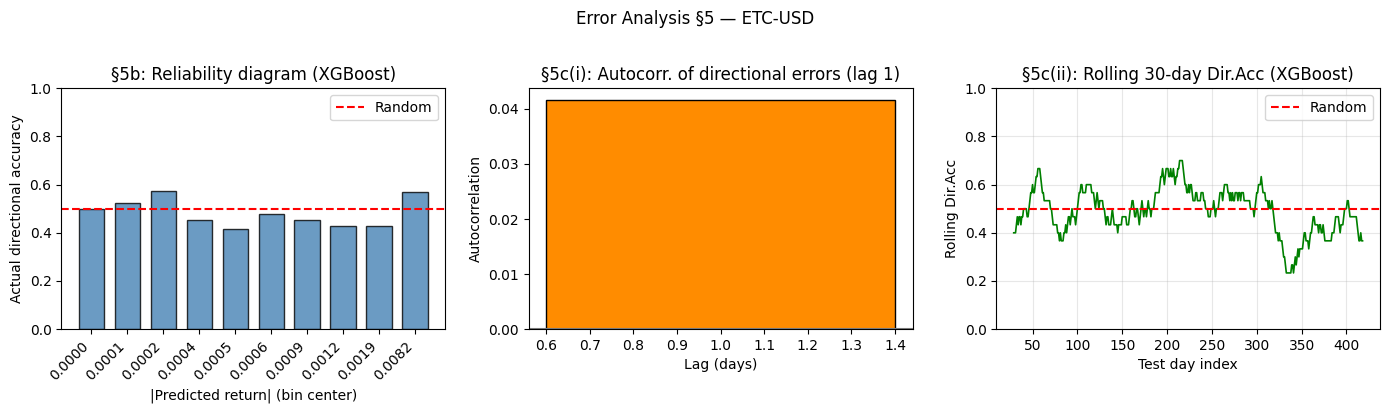


§5c(ii) Rolling 30-day Dir.Acc: periods above 0.5 indicate when the model is useful; sustained below 0.5 suggests avoiding the model in those windows.


In [29]:
# ── §5a: Regime-conditional evaluation (terciles by volatility_14) ──
vol_test = test_df["volatility_14"].values[N_LAGS : N_LAGS + len(y_test)]
vol_test = np.where(np.isnan(vol_test), np.nanmedian(vol_test), vol_test)

def metrics_per_tercile(mask, y_true, y_pred, prev_prices):
    if mask.sum() == 0:
        return {"mae_ret": np.nan, "rmse_ret": np.nan, "dir_acc": np.nan, "mae_price": np.nan, "n": 0}
    yt, yp = y_true[mask], y_pred[mask]
    pp = prev_prices[mask] if prev_prices is not None else None
    m = metrics_from_returns(yt, yp, pp)
    m["n"] = int(mask.sum())
    return m

# Use XGBoost and weighted ensemble (aligned lengths)
n_align = min(len(y_test), len(pred_xgb_test), len(vol_test))
yt_a = y_test[:n_align]
pred_xgb_a = pred_xgb_test[:n_align]
pp_a = pp_test[:n_align]
vol_a = vol_test[:n_align]
t_low  = vol_a <= np.nanpercentile(vol_a, 33.33)
t_mid  = (vol_a > np.nanpercentile(vol_a, 33.33)) & (vol_a <= np.nanpercentile(vol_a, 66.67))
t_high = vol_a > np.nanpercentile(vol_a, 66.67)

m_low  = metrics_per_tercile(t_low,  yt_a, pred_xgb_a, pp_a)
m_mid  = metrics_per_tercile(t_mid,  yt_a, pred_xgb_a, pp_a)
m_high = metrics_per_tercile(t_high, yt_a, pred_xgb_a, pp_a)

print("=== §5a: Regime-conditional evaluation (XGBoost, terciles by volatility_14) ===\n")
print(f"{'Tercile':<12} {'N':>6} {'MAE(ret)':>10} {'RMSE(ret)':>10} {'Dir.Acc':>8} {'MAE(price)':>10}")
print("-" * 58)
for label, m in [("Low vol", m_low), ("Mid vol", m_mid), ("High vol", m_high)]:
    print(f"{label:<12} {m['n']:>6} {m['mae_ret']:>10.6f} {m['rmse_ret']:>10.6f} {m['dir_acc']:>8.4f} {m.get('mae_price', np.nan):>10.4f}")
print("-" * 58)

# ── §5b: Calibration analysis (reliability diagram) ──
# Bin by |predicted return|; in each bin compute actual directional accuracy
abs_pred = np.abs(pred_xgb_a)
n_bins = 10
bins = np.percentile(abs_pred[np.isfinite(abs_pred)], np.linspace(0, 100, n_bins + 1))
bins[-1] += 1e-9
bin_da = []
bin_center = []
for i in range(n_bins):
    in_bin = (abs_pred >= bins[i]) & (abs_pred < bins[i+1])
    if in_bin.sum() < 5:
        continue
    correct = np.sign(yt_a[in_bin]) == np.sign(pred_xgb_a[in_bin])
    bin_da.append(np.mean(correct))
    bin_center.append((bins[i] + bins[i+1]) / 2)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Reliability: mean |pred| vs actual Dir.Acc per bin
if len(bin_center) > 0 and len(bin_da) > 0:
    x_pos = np.arange(len(bin_da))
    axes[0].bar(x_pos, bin_da, width=0.7, alpha=0.8, color="steelblue", edgecolor="black")
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels([f"{c:.4f}" for c in bin_center[:len(bin_da)]], rotation=45, ha="right")
    axes[0].axhline(0.5, color="red", linestyle="--", label="Random")
axes[0].set_xlabel("|Predicted return| (bin center)")
axes[0].set_ylabel("Actual directional accuracy")
axes[0].set_title("§5b: Reliability diagram (XGBoost)")
axes[0].legend()
axes[0].set_ylim(0, 1)

# ── §5c (i): Autocorrelation of directional errors ──
dir_correct = (np.sign(yt_a) == np.sign(pred_xgb_a)).astype(float)
dir_errors = 1.0 - dir_correct  # 1 = wrong, 0 = correct
from pandas import Series
acf_errors = Series(dir_errors).autocorr(lag=1)
axes[1].bar([1], [acf_errors], color="darkorange", edgecolor="black")
axes[1].axhline(0, color="gray", linestyle="-")
axes[1].set_xlabel("Lag (days)")
axes[1].set_ylabel("Autocorrelation")
axes[1].set_title("§5c(i): Autocorr. of directional errors (lag 1)")
if not np.isnan(acf_errors):
    print(f"\n§5c(i) Directional error autocorrelation (lag 1): {acf_errors:.4f}")

# ── §5c (ii): Rolling 30-day directional accuracy over test ──
window = 30
rolling_da = pd.Series(dir_correct).rolling(window, min_periods=window).mean()
axes[2].plot(rolling_da.values, color="green", linewidth=1.2)
axes[2].axhline(0.5, color="red", linestyle="--", label="Random")
axes[2].set_xlabel("Test day index")
axes[2].set_ylabel("Rolling Dir.Acc")
axes[2].set_title(f"§5c(ii): Rolling {window}-day Dir.Acc (XGBoost)")
axes[2].legend()
axes[2].set_ylim(0, 1)
axes[2].grid(alpha=0.3)

plt.suptitle(f"Error Analysis §5 — {ASSET}", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()
print("\n§5c(ii) Rolling 30-day Dir.Acc: periods above 0.5 indicate when the model is useful; sustained below 0.5 suggests avoiding the model in those windows.")

## 13. Long/Short Backtest

Ridge                    : P&L=+0.2443, Trades=175, Sharpe=0.22
XGBoost                  : P&L=-0.4811, Trades=146, Sharpe=-0.44
LSTM                     : P&L=-0.7816, Trades=70, Sharpe=-0.72
Ensemble (wt)            : P&L=-0.2477, Trades=140, Sharpe=-0.23


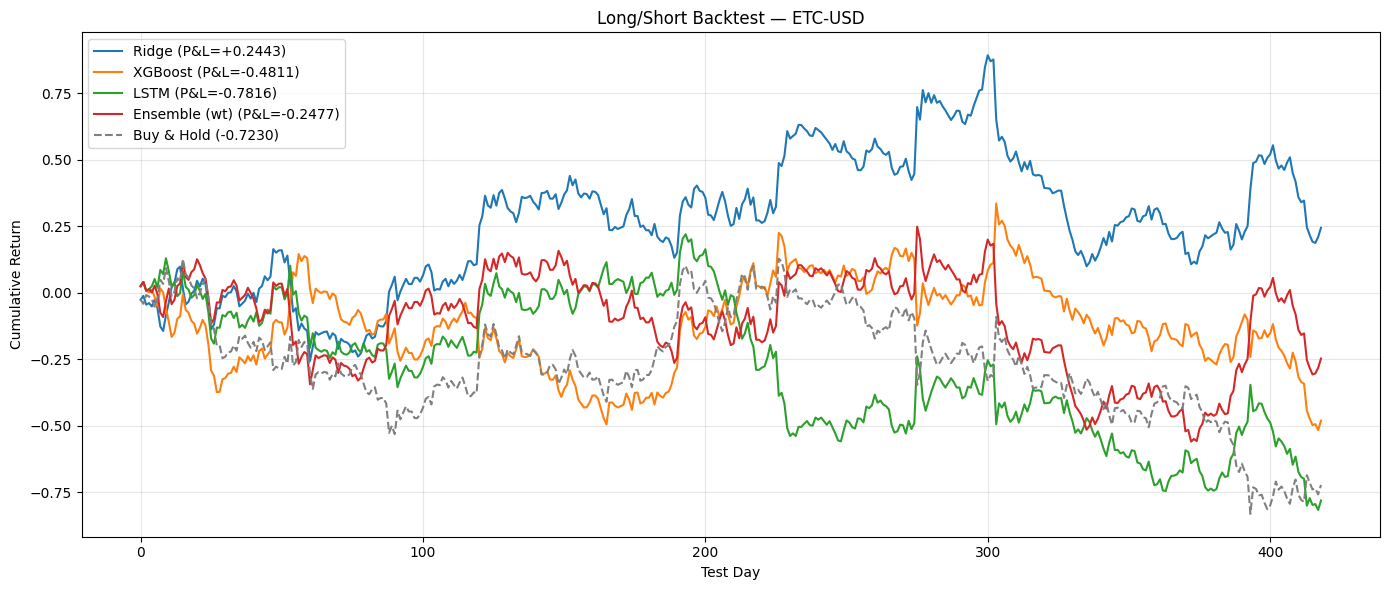

In [30]:
# ── Long/short backtest with transaction costs ──────────────
def backtest_long_short(actual_ret, pred_ret, threshold=0.0, cost_bps=10):
    """Long when pred > threshold, short when < -threshold, else flat."""
    actual_ret = np.asarray(actual_ret).ravel()
    pred_ret = np.asarray(pred_ret).ravel()
    position = 0
    pnl_list = []
    cost = cost_bps / 10_000.0
    n_trades = 0
    for t in range(len(actual_ret)):
        signal = 1 if pred_ret[t] > threshold else (-1 if pred_ret[t] < -threshold else 0)
        trade_cost = cost if signal != position else 0.0
        position = signal
        n_trades += int(trade_cost > 0)
        pnl_list.append(position * actual_ret[t] - trade_cost)
    return np.array(pnl_list), n_trades

# Backtest each model + ensemble
models_bt = [
    ("Ridge", pred_ridge_test, y_test),
    ("XGBoost", pred_xgb_test, y_test),
    ("LSTM", pred_lstm_test, y_te_lstm),
    ("Ensemble (wt)", pred_ens_wt, yt_common),
]

plt.figure(figsize=(14, 6))
for name, preds, yt in models_bt:
    n_bt = min(len(preds), len(yt))
    pnl, nt = backtest_long_short(yt[-n_bt:], preds[-n_bt:], threshold=0.0, cost_bps=10)
    cum_pnl = np.cumsum(pnl)
    sharpe = np.mean(pnl) / (np.std(pnl) + 1e-10) * np.sqrt(252)
    print(f"{name:25s}: P&L={cum_pnl[-1]:+.4f}, Trades={nt}, Sharpe={sharpe:.2f}")
    plt.plot(cum_pnl, label=f"{name} (P&L={cum_pnl[-1]:+.4f})")

# Buy and hold
bh = np.cumsum(y_test)
plt.plot(bh, label=f"Buy & Hold ({bh[-1]:+.4f})", linestyle="--", color="gray")

plt.xlabel("Test Day")
plt.ylabel("Cumulative Return")
plt.title(f"Long/Short Backtest — {ASSET}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 14. Summary

### v8 Improvements
1. **Return-based Ridge** — stationary features (return lags instead of price lags)
2. **22 new features** — RSI, MACD, Bollinger Band position, ATR(14), OBV change (7d/14d), multi-horizon returns (3d/7d/14d/30d), cyclical day/month signals, BTC cross-asset (lag 1–3), BTC-rotation proxy change
3. **XGBoost** — captures nonlinear feature interactions and regime effects
4. **Improved LSTM** — 64→32 units, dropout 0.2, early stopping (patience=15), ReduceLROnPlateau
5. **Weighted ensemble** — Ridge + XGBoost + LSTM, weighted by validation directional accuracy
6. **Training methodology (MODEL_IMPROVEMENT_ASSESSMENT.md §4):**
   - **§4b Expanding-window evaluation** — Walk-forward with multiple test windows; Ridge and XGBoost retrained on expanding train; report mean ± std of Dir.Acc and MAE_ret across windows (Section 9b).
   - **§4c Hyperparameter tuning** — Optuna (TPE sampler) for Ridge and XGBoost instead of RandomizedSearchCV for more efficient search.
   - **§4d LSTM validation** — Sequence construction documented so the last training sequence ends at the last row of the training slice (no validation data leakage).
7. **Stacking meta-learner (§3b)** — Logistic Regression trained on validation OOF predictions from Ridge, XGBoost, and LSTM; no leakage (meta-learner sees only val predictions, tested on test set). Directly optimizes directional signal.
8. **Direct XGBoost Classifier (§3c)** — Separate up/down classifier using `binary:logistic` objective + AUC-based CV tuning (`roc_auc` scoring). Training objective fully aligned with Dir.Acc metric; compare against regression-based Dir.Acc.
9. **Error analysis (MODEL_IMPROVEMENT_ASSESSMENT.md §5):** §5a Regime-conditional evaluation — test set split into terciles by volatility_14, MAE/RMSE/Dir.Acc reported per tercile (Section 12b). §5b Calibration — reliability diagram (Dir.Acc by bin of |predicted return|). §5c Temporal patterns — autocorrelation of directional errors (lag 1), rolling 30-day Dir.Acc over test.

### Key Findings
See comparison table (Section 9), expanding-window results (Section 9b), ablation (Section 10), and error analysis extensions (Section 12b) above.

**Assessment §3 (Model Selection) status:** §3a XGBoost regressor ✓ (Section 6), §3b Simple avg + weighted + stacking ensembles ✓ (Sections 8, 8b), §3c Direct classification ✓ (Section 8c).

In [31]:
# ── Sanity checks ────────────────────────────────────────────
assert X_train.shape[1] == N_LAGS + len(EXTRA_FEATURE_COLS), f"Feature count mismatch: {X_train.shape[1]}"
assert not np.isnan(pred_ridge_test).any(), "NaN in Ridge predictions"
assert not np.isnan(pred_xgb_test).any(), "NaN in XGBoost predictions"
assert not np.isnan(pred_lstm_test).any(), "NaN in LSTM predictions"
assert abs(w_ridge + w_xgb + w_lstm - 1.0) < 1e-6, "Ensemble weights don't sum to 1"
print("All sanity checks passed.")

All sanity checks passed.
